In [ ]:
#Qué hace: describe el tratamiento antibiótico (como prescripción) y su timing respecto a infección/UCI.
#Clave: antibiótico tratado como exposición observada, no como efecto.

In [1]:
# --- Pathogen–antibiotic descriptive analysis --------------------------------
# Objective:
#   Identify hospital admissions with microbiology-confirmed infections
#   of specific pathogens of interest and describe which antibiotics
#   were actually administered during the same admission.
#
# Pathogen groups of interest:
#   1) Enterobacterales (E. coli, Klebsiella spp., Enterobacter spp.)
#   2) Pseudomonas aeruginosa
#   3) Acinetobacter spp.
#   4) Stenotrophomonas maltophilia
#   5) Enterococcus faecium
#   6) Staphylococcus aureus
#
# Data:
#   - microbiologyevents  → organisms
#   - emar                → medication administration
#   - admissions          → admission window
# Notes:
#   - EMAR contains free-text medication names; matching is done by substring.
#   - This is a descriptive analysis (no dose or duration linkage yet).

In [2]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
PROJECT_ID = "mimic-pruebas"
HOSP = "physionet-data.mimiciv_3_1_hosp"
ICU  = "physionet-data.mimiciv_3_1_icu"

client = bigquery.Client(project=PROJECT_ID)

In [4]:
sql_pathogen_abx = f"""
WITH infected_hadm AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    LOWER(TRIM(me.org_name)) AS org_name_lc,
    a.admittime,
    a.dischtime
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
pathogen_grouped AS (
  SELECT
    subject_id,
    hadm_id,
    CASE
      WHEN org_name_lc LIKE '%escherichia coli%' OR org_name_lc LIKE '%e. coli%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%klebsiella%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%enterobacter %' OR org_name_lc LIKE 'enterobacter%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%pseudomonas aeruginosa%' OR org_name_lc LIKE '%p. aeruginosa%' THEN 'Pseudomonas aeruginosa'
      WHEN org_name_lc LIKE '%acinetobacter%' THEN 'Acinetobacter spp.'
      WHEN org_name_lc LIKE '%stenotrophomonas maltophilia%' OR org_name_lc LIKE '%s. maltophilia%' THEN 'Stenotrophomonas maltophilia'
      WHEN org_name_lc LIKE '%enterococcus faecium%' OR org_name_lc LIKE '%e. faecium%' THEN 'Enterococcus faecium'
      WHEN org_name_lc LIKE '%staphylococcus aureus%' OR org_name_lc LIKE '%s. aureus%' THEN 'Staphylococcus aureus'
      ELSE NULL
    END AS pathogen_group
  FROM infected_hadm
  WHERE org_name_lc IS NOT NULL
),
emar_norm AS (
  SELECT
    e.hadm_id,
    LOWER(e.medication) AS med_lc,
    e.charttime
  FROM `{HOSP}.emar` AS e
  WHERE e.medication IS NOT NULL
),
emar_in_window AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    en.med_lc
  FROM emar_norm en
  JOIN `{HOSP}.admissions` a
    ON en.hadm_id = a.hadm_id
  WHERE en.charttime BETWEEN a.admittime AND a.dischtime
),
combined AS (
  SELECT DISTINCT
    p.subject_id,
    p.hadm_id,
    p.pathogen_group,
    e.med_lc
  FROM pathogen_grouped p
  JOIN emar_in_window e
    ON p.hadm_id = e.hadm_id
)
SELECT
  pathogen_group,
  COUNT(DISTINCT subject_id) AS n_patients,
  COUNT(DISTINCT hadm_id) AS n_admissions,
  COUNT(DISTINCT med_lc) AS unique_antibiotics
FROM combined
WHERE pathogen_group IS NOT NULL
GROUP BY pathogen_group
ORDER BY n_patients DESC;
"""

df_pathogen_abx = client.query(sql_pathogen_abx).result().to_dataframe()
display(df_pathogen_abx)

E0000 00:00:1769593012.424290  947897 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,pathogen_group,n_patients,n_admissions,unique_antibiotics
0,Enterobacterales,7355,8397,1710
1,Pseudomonas aeruginosa,2030,2496,1240
2,Enterococcus faecium,829,898,1040
3,Stenotrophomonas maltophilia,394,447,842
4,Acinetobacter spp.,219,230,677
5,Staphylococcus aureus,115,115,362


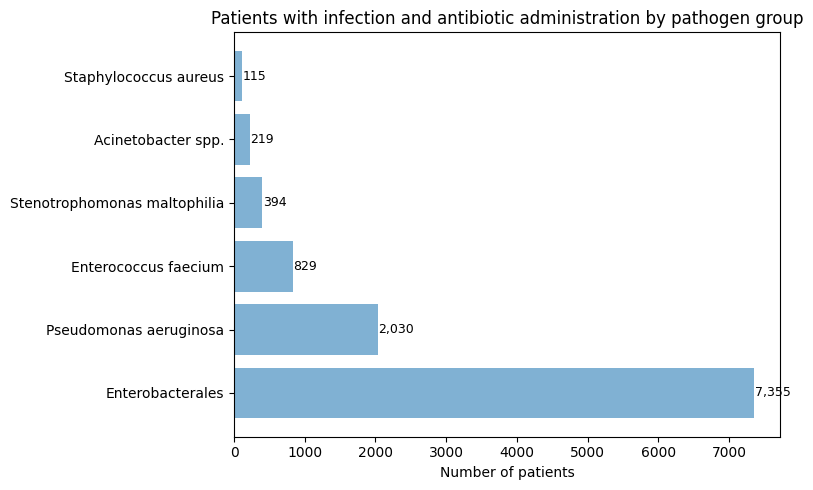

In [5]:
# --- Bar chart: infected patients by pathogen group -------------------------
plt.figure(figsize=(8,5))
bars = plt.barh(df_pathogen_abx["pathogen_group"], df_pathogen_abx["n_patients"], color="#80b1d3")
plt.title("Patients with infection and antibiotic administration by pathogen group")
plt.xlabel("Number of patients")
plt.tight_layout()

# Add counts on bars
for bar, value in zip(bars, df_pathogen_abx["n_patients"]):
    plt.text(value + 10, bar.get_y() + bar.get_height()/2, f"{value:,}", va='center', fontsize=9)

plt.show()

In [6]:
# NOTE:
# This analysis links microbiology-confirmed infections to actual antibiotic administrations (EMAR).
# The matching is based on admission ID (hadm_id), assuming the antibiotic was given within the
# same hospitalization window. This approach is descriptive and does not infer causality
# between a specific organism and a specific treatment episode.

In [7]:
# --- FIX: top antibiotics PER pathogen group
# Uses a window function to keep the top-K antibiotics within each pathogen group.
# This prevents the result from being dominated by the first group alphabetically.

TOP_K_PER_GROUP = 15  # adjust as needed

sql_top_abx_fixed = f"""
WITH infected_hadm AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    LOWER(TRIM(me.org_name)) AS org_name_lc,
    a.admittime,
    a.dischtime
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
pathogen_grouped AS (
  SELECT
    subject_id,
    hadm_id,
    CASE
      WHEN org_name_lc LIKE '%escherichia coli%' OR org_name_lc LIKE '%e. coli%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%klebsiella%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%enterobacter %' OR org_name_lc LIKE 'enterobacter%' THEN 'Enterobacterales'
      WHEN org_name_lc LIKE '%pseudomonas aeruginosa%' OR org_name_lc LIKE '%p. aeruginosa%' THEN 'Pseudomonas aeruginosa'
      WHEN org_name_lc LIKE '%acinetobacter%' THEN 'Acinetobacter spp.'
      WHEN org_name_lc LIKE '%stenotrophomonas maltophilia%' OR org_name_lc LIKE '%s. maltophilia%' THEN 'Stenotrophomonas maltophilia'
      WHEN org_name_lc LIKE '%enterococcus faecium%' OR org_name_lc LIKE '%e. faecium%' THEN 'Enterococcus faecium'
      WHEN org_name_lc LIKE '%staphylococcus aureus%' OR org_name_lc LIKE '%s. aureus%' THEN 'Staphylococcus aureus'
      ELSE NULL
    END AS pathogen_group
  FROM infected_hadm
  WHERE org_name_lc IS NOT NULL
),
emar_norm AS (
  SELECT
    e.hadm_id,
    LOWER(e.medication) AS med_lc,
    e.charttime
  FROM `{HOSP}.emar` AS e
  WHERE e.medication IS NOT NULL
),
emar_in_window AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    en.med_lc
  FROM emar_norm en
  JOIN `{HOSP}.admissions` a
    ON en.hadm_id = a.hadm_id
  WHERE en.charttime BETWEEN a.admittime AND a.dischtime
),
combined AS (
  SELECT DISTINCT
    p.subject_id,
    p.hadm_id,
    p.pathogen_group,
    e.med_lc
  FROM pathogen_grouped p
  JOIN emar_in_window e
    ON p.hadm_id = e.hadm_id
),
counts AS (
  SELECT
    pathogen_group,
    med_lc,
    COUNT(DISTINCT hadm_id) AS n_admissions
  FROM combined
  WHERE pathogen_group IS NOT NULL
  GROUP BY 1,2
),
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY pathogen_group
      ORDER BY n_admissions DESC, med_lc
    ) AS rn
  FROM counts
)
SELECT pathogen_group, med_lc, n_admissions
FROM ranked
WHERE rn <= {TOP_K_PER_GROUP}
ORDER BY pathogen_group, n_admissions DESC, med_lc
"""

df_top_abx = client.query(sql_top_abx_fixed).result().to_dataframe()
display(df_top_abx.head(20))

E0000 00:00:1769593016.953260  947897 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,pathogen_group,med_lc,n_admissions
0,Acinetobacter spp.,sodium chloride 0.9% flush,223
1,Acinetobacter spp.,acetaminophen,188
2,Acinetobacter spp.,heparin,185
3,Acinetobacter spp.,vancomycin,154
4,Acinetobacter spp.,senna,147
5,Acinetobacter spp.,cefepime,132
6,Acinetobacter spp.,insulin,128
7,Acinetobacter spp.,polyethylene glycol,119
8,Acinetobacter spp.,heparin flush (10 units/ml),114
9,Acinetobacter spp.,acetaminophen iv,112


/tmp/ipykernel_947897/1817516302.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


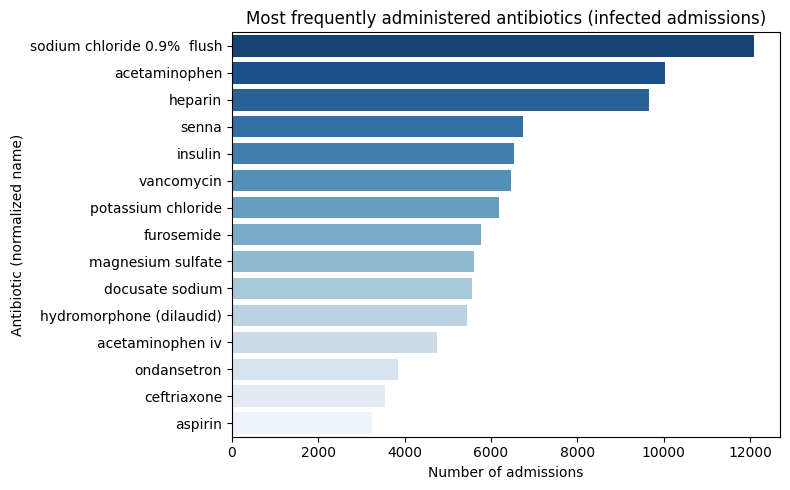

In [8]:
# Aggregate over all pathogen groups
top_abx = (
    df_top_abx.groupby("med_lc", as_index=False)["n_admissions"]
    .sum()
    .sort_values("n_admissions", ascending=False)
    .head(15)
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_abx,
    y="med_lc", x="n_admissions",
    palette="Blues_r"
)
plt.title("Most frequently administered antibiotics (infected admissions)")
plt.xlabel("Number of admissions")
plt.ylabel("Antibiotic (normalized name)")
plt.tight_layout()
plt.show()

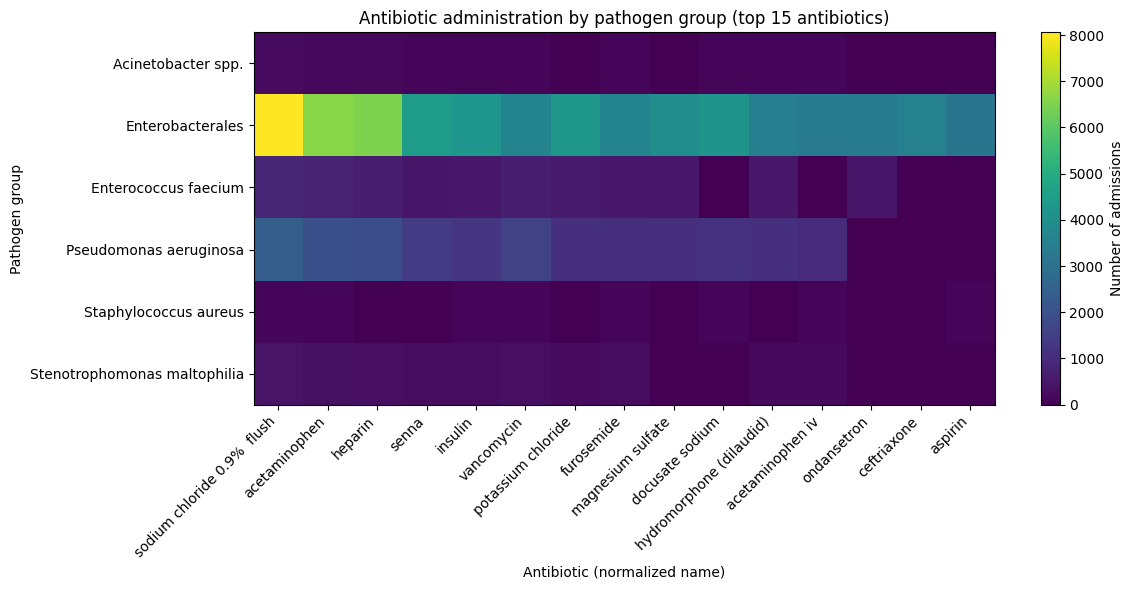

In [9]:
# --- Heatmap: antibiotics by pathogen group (matplotlib-only) ----------------
# This version does not require seaborn. It:
#  1) builds a pivot table,
#  2) coerces values to float,
#  3) optionally selects top-N antibiotics to reduce clutter,
#  4) renders with imshow + colorbar.

# 1) Pivot (rows=pathogen, cols=antibiotic, values=# admissions)
pivot = (
    df_top_abx.pivot_table(
        index="pathogen_group",
        columns="med_lc",
        values="n_admissions",
        aggfunc="sum",
        fill_value=0
    )
)

# 2) Keep top-N antibiotics overall (prevents unreadable, wide charts)
TOP_N = 15
top_cols = pivot.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
pivot = pivot[top_cols]

# 3) Coerce to numeric float array (avoid dtype object errors)
matrix = pd.to_numeric(pivot.values.ravel(), errors="coerce").reshape(pivot.shape).astype(float)

# 4) Plot with matplotlib
plt.figure(figsize=(12, 6))
im = plt.imshow(matrix, aspect="auto")  # default colormap; no custom colors per your policy
plt.colorbar(im, label="Number of admissions")

# Axis ticks/labels
plt.xticks(ticks=np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(pivot.index)),   labels=pivot.index)

plt.title("Antibiotic administration by pathogen group (top 15 antibiotics)")
plt.xlabel("Antibiotic (normalized name)")
plt.ylabel("Pathogen group")
plt.tight_layout()
plt.show()

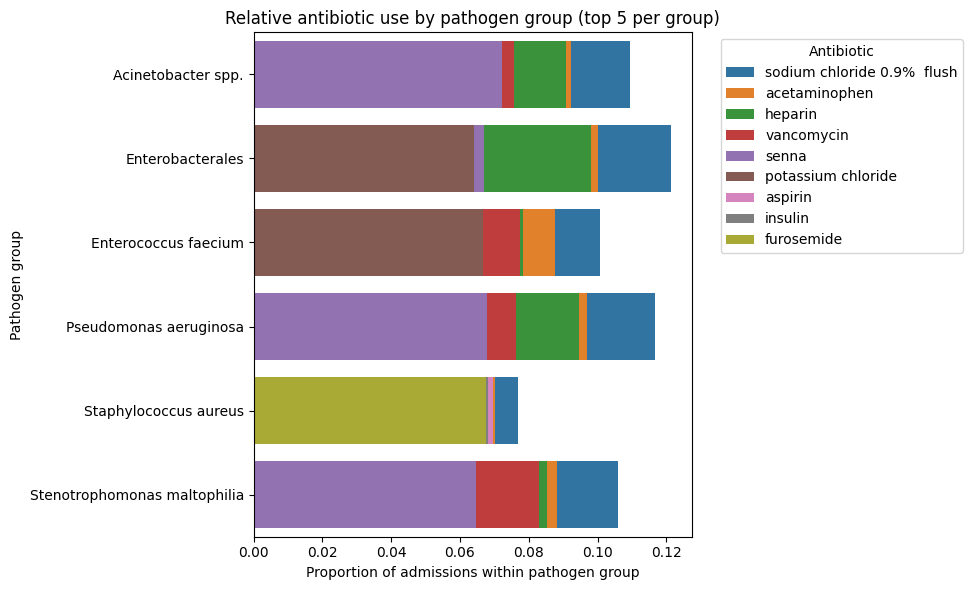

In [10]:
# --- Relative antibiotic usage by pathogen group -----------------------------
df_prop = df_top_abx.copy()
df_prop["total_per_group"] = df_prop.groupby("pathogen_group")["n_admissions"].transform("sum")
df_prop["prop"] = df_prop["n_admissions"] / df_prop["total_per_group"]

# Keep top 5 antibiotics per group for clarity
df_prop = (
    df_prop.sort_values(["pathogen_group", "prop"], ascending=[True, False])
    .groupby("pathogen_group")
    .head(5)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_prop,
    x="prop", y="pathogen_group", hue="med_lc",
    dodge=False
)
plt.title("Relative antibiotic use by pathogen group (top 5 per group)")
plt.xlabel("Proportion of admissions within pathogen group")
plt.ylabel("Pathogen group")
plt.legend(title="Antibiotic", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
# --- Cohort: pathogen-antibiotic pairs restricted to 6 clinical blocks -------
# Blocks:
# 1) Enterobacterales (E. coli, Klebsiella spp., Enterobacter spp.) + ceftriaxone/cefepime/ceftazidime
# 2) Enterobacterales + meropenem/imipenem
# 3) Pseudomonas aeruginosa OR Acinetobacter spp. + meropenem/imipenem
# 4) Stenotrophomonas maltophilia + trimethoprim-sulfamethoxazole
# 5) Enterococcus faecium + vancomycin
# 6) Staphylococcus aureus (MSSA/MRSA) + oxacillin
#
# Notes:
# - Microbiology and EMAR are matched within the same hospital admission (hadm_id).
# - EMAR medication is matched via lowercase substring; extend synonyms if needed.

In [12]:
sql_blocks_filtered = f"""
WITH infected AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    CASE
      WHEN LOWER(TRIM(me.org_name)) LIKE '%escherichia coli%' OR LOWER(TRIM(me.org_name)) LIKE '%e. coli%' THEN 'Enterobacterales'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%klebsiella%' THEN 'Enterobacterales'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%enterobacter %' OR LOWER(TRIM(me.org_name)) LIKE 'enterobacter%' THEN 'Enterobacterales'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%pseudomonas aeruginosa%' OR LOWER(TRIM(me.org_name)) LIKE '%p. aeruginosa%' THEN 'Pseudomonas aeruginosa'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%acinetobacter%' THEN 'Acinetobacter spp.'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%stenotrophomonas maltophilia%' OR LOWER(TRIM(me.org_name)) LIKE '%s. maltophilia%' THEN 'Stenotrophomonas maltophilia'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%enterococcus faecium%' OR LOWER(TRIM(me.org_name)) LIKE '%e. faecium%' THEN 'Enterococcus faecium'
      WHEN LOWER(TRIM(me.org_name)) LIKE '%staphylococcus aureus%' OR LOWER(TRIM(me.org_name)) LIKE '%s. aureus%' THEN 'Staphylococcus aureus'
      ELSE NULL
    END AS pathogen_group
  FROM `{HOSP}.microbiologyevents` AS me
  JOIN `{HOSP}.admissions` AS a
    ON me.hadm_id = a.hadm_id
  WHERE (
    LOWER(COALESCE(me.interpretation, '')) LIKE '%positive%'
    OR me.org_name IS NOT NULL
  )
  AND me.charttime BETWEEN a.admittime AND a.dischtime
),
emar_norm AS (
  SELECT
    a.subject_id,
    a.hadm_id,
    LOWER(TRIM(e.medication)) AS med_lc
  FROM `{HOSP}.emar` AS e
  JOIN `{HOSP}.admissions` AS a
    ON e.hadm_id = a.hadm_id
  WHERE e.medication IS NOT NULL
    AND e.charttime BETWEEN a.admittime AND a.dischtime
),
abx_map AS (
  SELECT
    subject_id,
    hadm_id,
    CASE
      WHEN med_lc LIKE '%ceftriaxone%' THEN 'ceftriaxone'
      WHEN med_lc LIKE '%cefepime%' THEN 'cefepime'
      WHEN med_lc LIKE '%ceftazidime%' THEN 'ceftazidime'
      WHEN med_lc LIKE '%meropenem%' THEN 'meropenem'
      WHEN med_lc LIKE '%imipenem%' THEN 'imipenem'
      WHEN med_lc LIKE '%trimethoprim%' OR med_lc LIKE '%sulfamethoxazole%' OR med_lc LIKE '%co-trimoxazole%' OR med_lc LIKE '%co trimoxazole%' OR med_lc LIKE '%tmp-smx%' THEN 'trimethoprim-sulfamethoxazole'
      WHEN med_lc LIKE '%vancomycin%' THEN 'vancomycin'
      WHEN med_lc LIKE '%oxacillin%' THEN 'oxacillin'
      ELSE NULL
    END AS antibiotic
  FROM emar_norm
),
joined AS (
  SELECT DISTINCT
    i.subject_id,
    i.hadm_id,
    i.pathogen_group,
    a.antibiotic
  FROM infected i
  JOIN abx_map a
    ON i.hadm_id = a.hadm_id
  WHERE i.pathogen_group IS NOT NULL
    AND a.antibiotic IS NOT NULL
),
-- Keep only the 6 clinically valid pathogen–antibiotic blocks
blocks AS (
  SELECT
    subject_id,
    hadm_id,
    pathogen_group,
    antibiotic,
    CASE
      -- 1) Enterobacterales + ceftriaxone/cefepime/ceftazidime
      WHEN pathogen_group = 'Enterobacterales'
           AND antibiotic IN ('ceftriaxone','cefepime','ceftazidime')
        THEN 'B1_Enterobacterales_Ceph3_4'
      -- 2) Enterobacterales + meropenem/imipenem
      WHEN pathogen_group = 'Enterobacterales'
           AND antibiotic IN ('meropenem','imipenem')
        THEN 'B2_Enterobacterales_Carbapenem'
      -- 3) Pseudomonas OR Acinetobacter + meropenem/imipenem
      WHEN pathogen_group IN ('Pseudomonas aeruginosa','Acinetobacter spp.')
           AND antibiotic IN ('meropenem','imipenem')
        THEN 'B3_PseudoOrAcinetobacter_Carbapenem'
      -- 4) Stenotrophomonas + TMP-SMX
      WHEN pathogen_group = 'Stenotrophomonas maltophilia'
           AND antibiotic = 'trimethoprim-sulfamethoxazole'
        THEN 'B4_Stenotrophomonas_TMPSMX'
      -- 5) Enterococcus faecium + vancomycin
      WHEN pathogen_group = 'Enterococcus faecium'
           AND antibiotic = 'vancomycin'
        THEN 'B5_Efaecium_Vancomycin'
      -- 6) Staphylococcus aureus + oxacillin
      WHEN pathogen_group = 'Staphylococcus aureus'
           AND antibiotic = 'oxacillin'
        THEN 'B6_StaphAureus_Oxacillin'
      ELSE NULL
    END AS block_name
  FROM joined
)
SELECT
  block_name,
  pathogen_group,
  antibiotic,
  COUNT(DISTINCT subject_id) AS n_patients,
  COUNT(DISTINCT hadm_id)    AS n_admissions
FROM blocks
WHERE block_name IS NOT NULL
GROUP BY block_name, pathogen_group, antibiotic
ORDER BY block_name, n_admissions DESC
"""

df_blocks_filtered = client.query(sql_blocks_filtered).result().to_dataframe()
display(df_blocks_filtered)

E0000 00:00:1769593022.756970  947897 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


,block_name,pathogen_group,antibiotic,n_patients,n_admissions
0,B1_Enterobacterales_Ceph3_4,Enterobacterales,ceftriaxone,3368,3559
1,B1_Enterobacterales_Ceph3_4,Enterobacterales,cefepime,2221,2331
2,B1_Enterobacterales_Ceph3_4,Enterobacterales,ceftazidime,598,625
3,B2_Enterobacterales_Carbapenem,Enterobacterales,meropenem,1261,1432
4,B2_Enterobacterales_Carbapenem,Enterobacterales,imipenem,9,9
5,B3_PseudoOrAcinetobacter_Carbapenem,Pseudomonas aeruginosa,meropenem,446,537
6,B3_PseudoOrAcinetobacter_Carbapenem,Acinetobacter spp.,meropenem,57,60
7,B3_PseudoOrAcinetobacter_Carbapenem,Pseudomonas aeruginosa,imipenem,6,6
8,B3_PseudoOrAcinetobacter_Carbapenem,Acinetobacter spp.,imipenem,1,1
9,B4_Stenotrophomonas_TMPSMX,Stenotrophomonas maltophilia,trimethoprim-sulfamethoxazole,195,216
